# Home Exercise on Neural Network
> Implement a Neural Network model using fully **connected layers**, **non-linear activation**, **skip connections**, **dropout**, etc. (Note that you are *only allowed to use MLP blocks and must not use CNNs, Transformers, or other advanced deep learning architectures*) (Can train on a 10GB GPU ). 

Data: [MNIST datasets](https://www.kaggle.com/competitions/digit-recognizer/data) 

In [1]:
!kaggle competitions download -c digit-recognizer

  0%|                                               | 0.00/15.3M [00:00<?, ?B/s]
100%|███████████████████████████████████████| 15.3M/15.3M [00:00<00:00, 209MB/s]


In [1]:
import os, shutil
import zipfile
import numpy as np
import pandas as pd

## Load the dataset

In [2]:
import zipfile
def unzip_file(path, des, delete=True):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    with zipfile.ZipFile(path) as zipref:
        zipref.extractall(des)
        print(f"Extracted zipfile in {des}")
    if delete:
        os.remove(path)
        return
    
data_dir = "./data"
zip_path = os.path.join(data_dir, "digit-recognizer.zip")
unzip_file(zip_path, data_dir, True)

Extracted zipfile in ./data


In [9]:
print(os.listdir(data_dir))

['sample_submission.csv', 'test.csv', 'train.csv']


In [3]:
train_path = os.path.join(data_dir,"train.csv")
test_path = os.path.join(data_dir,"test.csv")
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

In [4]:
print(train_data.columns)

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)


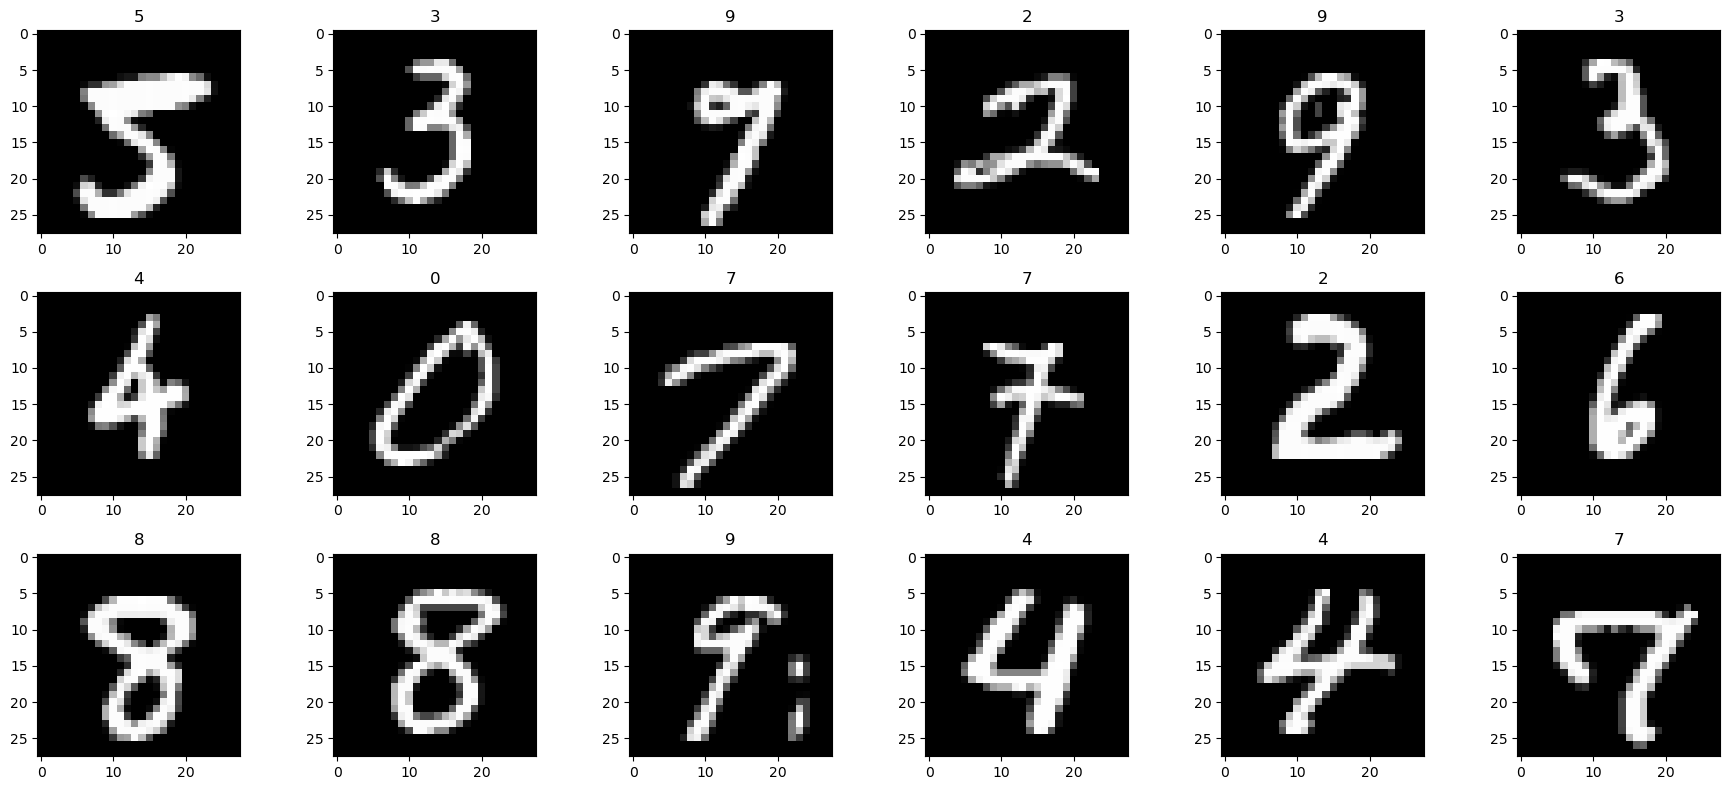

In [5]:
import matplotlib.pyplot as plt
def show_image(train_image, label, index):
    image_shaped = train_image.values.reshape(28,28)
    plt.subplot(3, 6, index+1)
    plt.imshow(image_shaped, cmap=plt.cm.gray)
    plt.title(label)


plt.figure(figsize=(18, 8))
sample_image = train_data.sample(18).reset_index(drop=True)
for index, row in sample_image.iterrows():
    label = row['label']
    image_pixels = row.drop('label')
    show_image(image_pixels, label, index)
plt.tight_layout()

## Data preprocessing

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [14]:
# Convert images into float vectors
X = train_data.drop(labels='label', axis=1).values.astype(np.float64)
y = train_data['label'].values.astype(np.int64)

X_test_submission = test_data.values.astype(np.float64)
# MNIST normalization constants
MNIST_MEAN = 0.1307
MNIST_STD  = 0.3081
RND = 42

if 'label' not in train_data.columns:
    raise ValueError("train_data must include 'label' column")

X_train, X_temp, y_train, y_temp = train_test_split(
    X,y, test_size=0.2, random_state=RND, stratify=y
)

X_val, X_test_from_train, y_val, y_test_from_train = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RND, stratify=y_temp
)

print(f"Sizes -> train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test_from_train)}")

Sizes -> train: 33600, val: 4200, test: 4200


In [12]:
print(X_train[1])

[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.  60. 141. 141. 216. 253. 253. 255.
 178. 141.  41.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  63. 234. 252. 253. 240. 215. 252. 253.
 252. 252. 252. 101.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.  23. 234. 224. 168.  56.  43.  19.  56.  56.
  56. 171. 252. 235.  28.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0. 

## Build the MNISTFLat Dataset

In [15]:
class MNISTFlatDataset(Dataset):
    def __init__(self, X, y=None, transform=None, normalize=True):
        self.X = X
        self.y = y if y is None else np.asarray(y, dtype=np.int64)
        self.transform = transform
        self.normalize = normalize
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img = self.X[idx]
        
        if self.normalize:
            img = img / 255.0
            
        if self.transform:
            img = self.transform(img)
            
        if self.normalize:
            img = (img - MNIST_MEAN) / MNIST_STD
            
        img_tensor = torch.from_numpy(img).float()
        if self.y is None:
            return img_tensor
        label = int(self.y[idx])
        return img_tensor, label
        

### DataLoaders

In [17]:
train_ds = MNISTFlatDataset(X_train, y_train, transform=None, normalize=None)
test_ds = MNISTFlatDataset(X_test_from_train, y_test_from_train, transform=None, normalize=None)
val_ds = MNISTFlatDataset(X_val, y_val, transform=None, normalize=None)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [18]:
batch = next(iter(train_loader))
images, labels = batch
print("Batch images shape:", images.shape)  # expected (batch_size, 784) (last batch may be smaller)
print("Batch labels shape:", labels.shape)
print("Pixel stats (first batch): mean {:.4f}, std {:.4f}".format(images.mean().item(), images.std().item()))

Batch images shape: torch.Size([128, 784])
Batch labels shape: torch.Size([128])
Pixel stats (first batch): mean 32.5417, std 77.9817


## Build the Neural Network model (MLP)

### parameters

In [20]:
import math

input_dim = 28*28
n_layers = 8
hidden_dim = 1024
num_classes = 10
dropout = 0.3
activation = "gelu"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_activation(name="gelu"):
    name = name.lower()
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "gelu":
        return nn.GELU()
    if name == "swish":
        try:
            return nn.SiLU()  # SiLU ~ swish
        except:
            return nn.GELU()
    return nn.GELU()

In [21]:
class MLPBlock(nn.Module):
    def __init__(self, in_features, out_features, activation="gelu", dropout=0.0, use_layernorm=True):
        super().__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.act = get_activation(activation)
        self.dropout = nn.Dropout(dropout) if dropout>0 else nn.Identity()
        self.use_ln = use_layernorm
        self.ln = nn.LayerNorm(out_features) if use_layernorm else nn.Identity()

    def forward(self, x):
        x = self.fc(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.ln(x)
        return x

# Full MLP with optional residual connections when dims match
class ResidualMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=1024, n_layers=8, num_classes=10, dropout=0.3, activation="gelu", use_layernorm=True):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.blocks = nn.ModuleList()
        for i in range(n_layers):
            self.blocks.append(MLPBlock(hidden_dim, hidden_dim, activation=activation, dropout=dropout, use_layernorm=use_layernorm))
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim) if use_layernorm else nn.Identity(),
            nn.Linear(hidden_dim, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)
        for blk in self.blocks:
            out = blk(x)
            if out.shape == x.shape:
                x = x + out
            else:
                x = out
        logits = self.head(x)
        return logits

In [22]:
model = ResidualMLP(input_dim=input_dim, hidden_dim=hidden_dim, n_layers=n_layers,
                    num_classes=num_classes, dropout=dropout, activation=activation, use_layernorm=True)
model = model.to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"Model params: {count_params(model):,} parameters")
# Forward check with a dummy batch (use batch size same as your DataLoader)
batch_size = 16
dummy = torch.randn(batch_size, input_dim, device=device)
with torch.no_grad():
    out = model(dummy)
print("Dummy forward output shape:", out.shape)   # expect (batch_size, 10)

# Return model for use later (if running in interactive notebook)
# model  # uncomment if you want the notebook to show the model architecture

Device: cuda
Model params: 9,229,322 parameters
Dummy forward output shape: torch.Size([16, 10])
